In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_breast_cancer

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


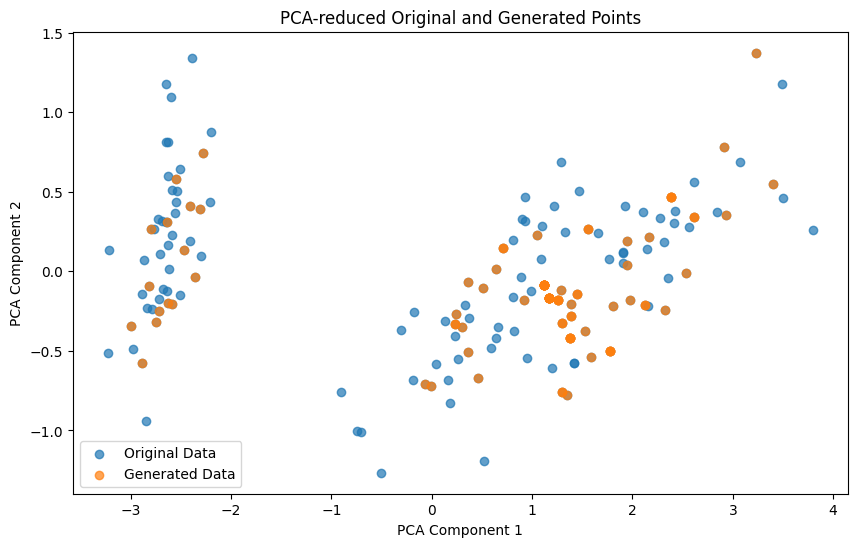

In [18]:
def decision_tree_data_generation(df, target_column, max_depth=None, n_generated_points=100):
    """
    Overfits a decision tree on the given dataframe, extracts its rules, generates new data points,
    and plots PCA-reduced scatter plots of original and generated data.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - max_depth: Maximum depth of the decision tree (None for no limit).
    - n_generated_points: Number of new data points to generate.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Overfit a decision tree
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree.fit(X, y)
    
    # Extract rules
    tree_rules = export_text(tree, feature_names=list(X.columns))
    #print("Extracted Rules:\n", tree_rules)
    
    # Generate new data points
    def generate_from_tree(tree, X, n_samples):
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        generated_data = []
        for _ in range(n_samples):
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = matching_rows.sample(1).values.flatten() if len(matching_rows) > 0 else X.sample(1).values.flatten()
            generated_data.append(sample)
        return np.array(generated_data)
    
    X_leaves = pd.DataFrame(X)
    generated_points = generate_from_tree(tree, X_leaves, n_generated_points)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    generated_points_2d = pca.transform(generated_points)
    
    # Plot original and generated points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0], original_points_2d[:, 1], label="Original Data", alpha=0.7)
    plt.scatter(generated_points_2d[:, 0], generated_points_2d[:, 1], label="Generated Data", alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Example usage
from sklearn.datasets import load_iris
iris = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

decision_tree_data_generation(df_iris, target_column='target', max_depth=3, n_generated_points=100)

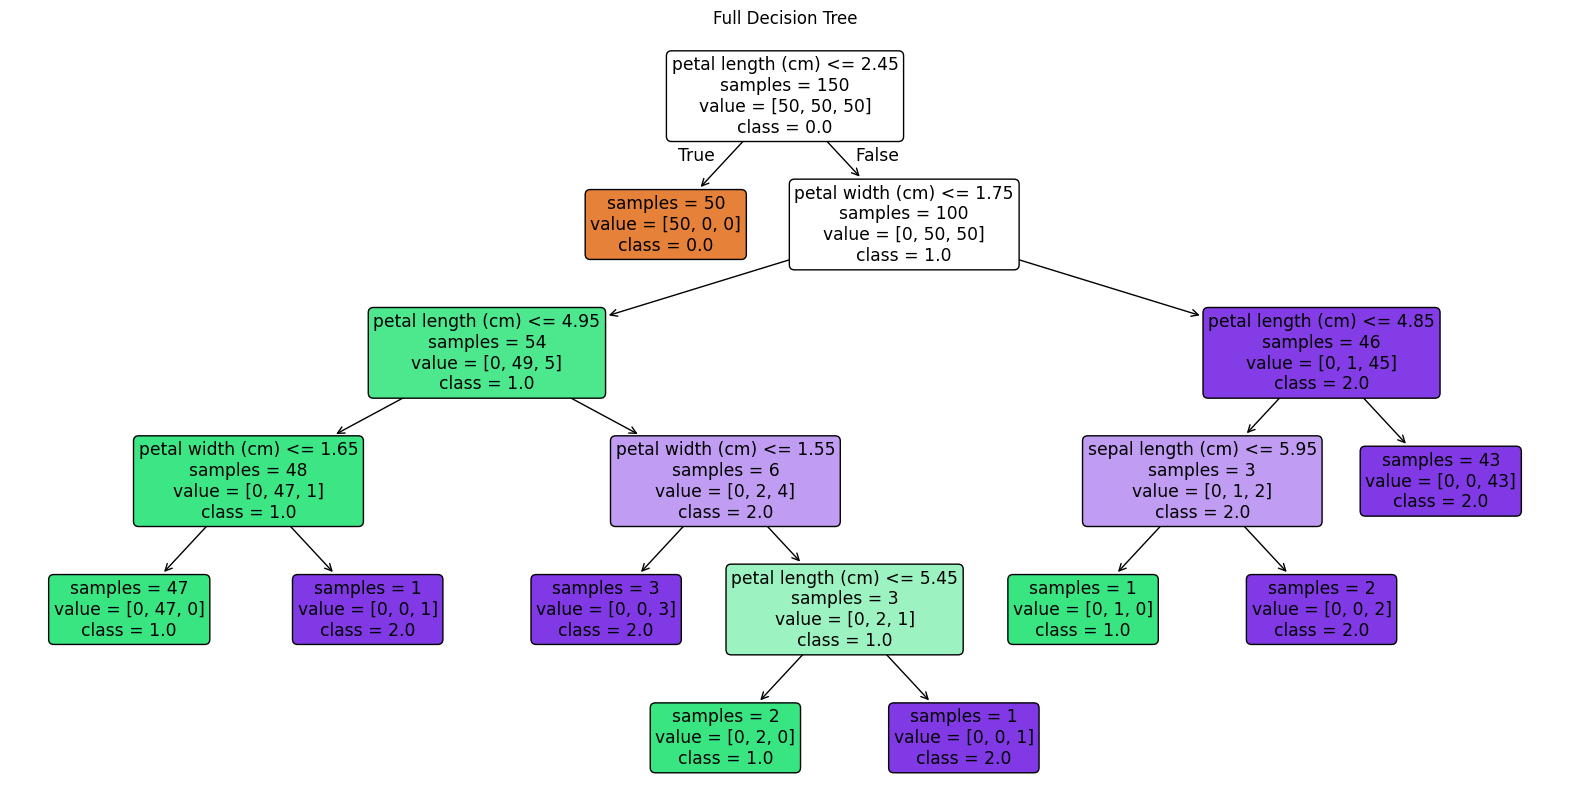

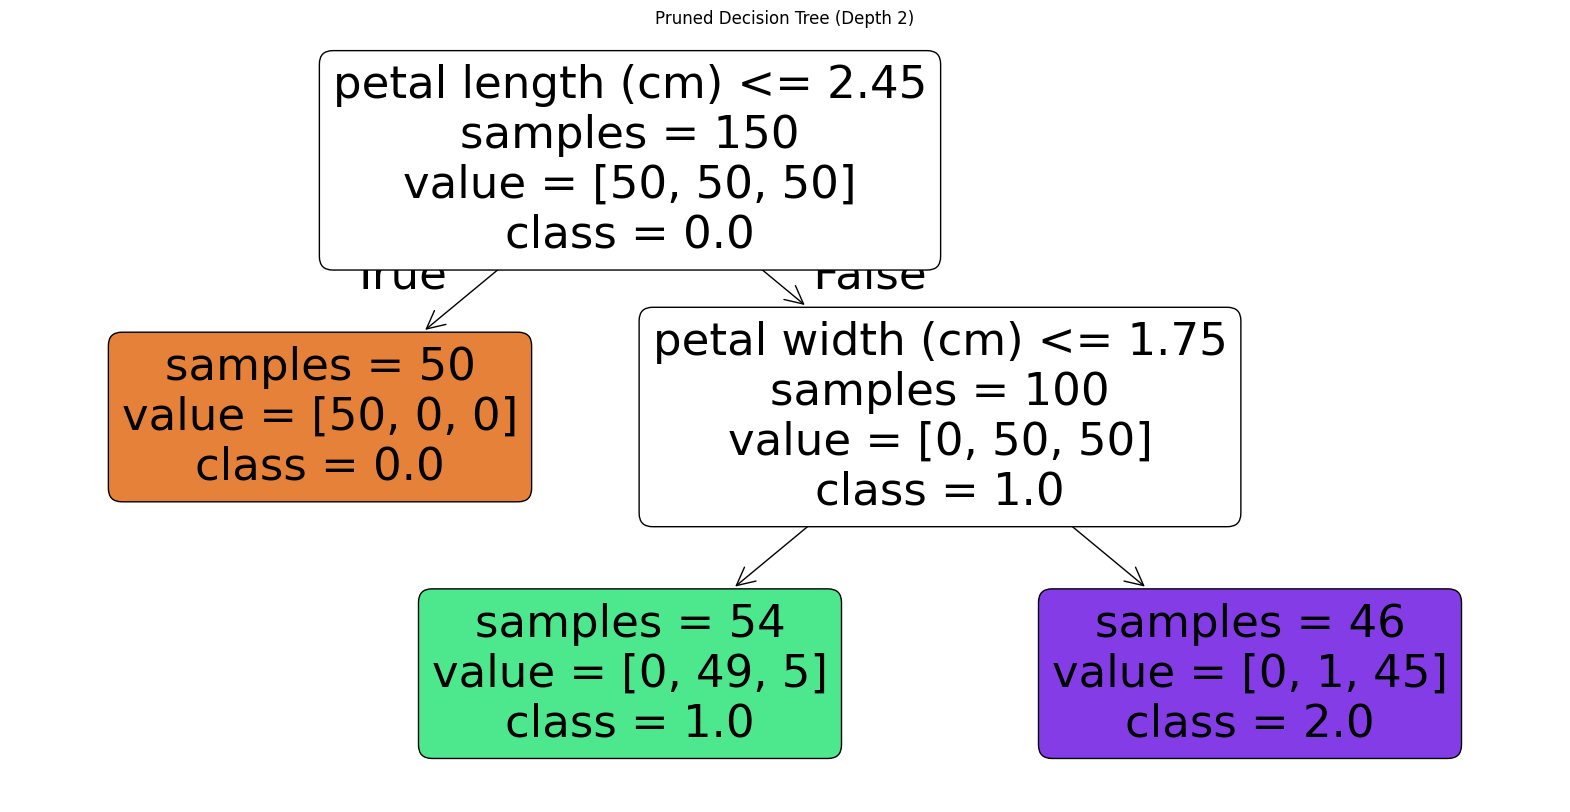

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


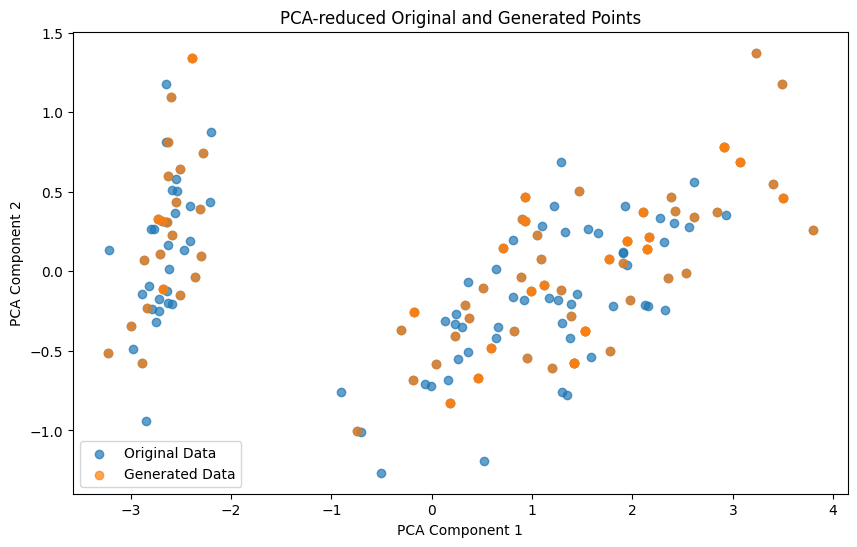

In [17]:
def plot_decision_tree(tree, feature_names, class_names, title):
    """
    Plots the decision tree using matplotlib.
    
    Parameters:
    - tree: The decision tree classifier.
    - feature_names: List of feature names.
    - class_names: List of class names.
    - title: Title of the plot.
    """
    plt.figure(figsize=(20, 10))
    plot_tree(tree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, impurity=False)
    plt.title(title)
    plt.show()

def decision_tree_data_generation_with_pruning(
    df, target_column, max_depth=None, prune_depth=None, n_generated_points=100
):
    """
    Overfits a decision tree on the given dataframe, allows pruning by level, extracts rules,
    generates new data points, and plots PCA-reduced scatter plots of original and generated data.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - max_depth: Maximum depth of the decision tree (None for no limit).
    - prune_depth: Maximum depth of the tree used for data generation.
    - n_generated_points: Number of new data points to generate.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    feature_names = X.columns.tolist()
    class_names = [str(cls) for cls in np.unique(y)]
    
    # Overfit a decision tree
    full_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    full_tree.fit(X, y)
    
    # Plot the full tree
    plot_decision_tree(full_tree, feature_names, class_names, "Full Decision Tree")
    
    # Prune the tree
    if prune_depth is not None:
        pruned_tree = DecisionTreeClassifier(max_depth=prune_depth, random_state=42)
        pruned_tree.fit(X, y)
        
        # Plot the pruned tree
        plot_decision_tree(pruned_tree, feature_names, class_names, f"Pruned Decision Tree (Depth {prune_depth})")
    else:
        pruned_tree = full_tree
    
    # Generate new data points based on the pruned tree
    def generate_from_tree(tree, X, n_samples):
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        generated_data = []
        for _ in range(n_samples):
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = (
                matching_rows.sample(1).values.flatten()
                if len(matching_rows) > 0
                else X.sample(1).values.flatten()
            )
            generated_data.append(sample)
        return np.array(generated_data)

    generated_points = generate_from_tree(pruned_tree, X, n_generated_points)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    generated_points_2d = pca.transform(generated_points)
    
    # Plot original and generated points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0], original_points_2d[:, 1], label="Original Data", alpha=0.7)
    plt.scatter(generated_points_2d[:, 0], generated_points_2d[:, 1], label="Generated Data", alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Example usage
from sklearn.datasets import load_iris
iris = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

decision_tree_data_generation_with_pruning(
    df_iris, target_column='target', max_depth=15, prune_depth=2, n_generated_points=100
)

In [10]:
def plot_decision_tree(tree, feature_names, class_names, title):
    """
    Plots the decision tree using matplotlib.
    
    Parameters:
    - tree: The decision tree classifier.
    - feature_names: List of feature names.
    - class_names: List of class names.
    - title: Title of the plot.
    """
    plt.figure(figsize=(20, 10))
    plot_tree(tree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, impurity=False)
    plt.title(title)
    plt.show()

def decision_tree_data_generation_with_pruning(
    df, target_column, max_depth=None, prune_depth=None, n_generated_points=100
):
    """
    Overfits a decision tree on the given dataframe, allows pruning by level, extracts rules,
    generates new data points, and plots PCA-reduced scatter plots of original and generated data.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - max_depth: Maximum depth of the decision tree (None for no limit).
    - prune_depth: Maximum depth of the tree used for data generation.
    - n_generated_points: Number of new data points to generate.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    feature_names = X.columns.tolist()
    class_names = [str(cls) for cls in np.unique(y)]
    
    # Overfit a decision tree
    full_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    full_tree.fit(X, y)
    
    # Plot the full tree
    plot_decision_tree(full_tree, feature_names, class_names, "Full Decision Tree")
    
    # Prune the tree
    if prune_depth is not None:
        pruned_tree = DecisionTreeClassifier(max_depth=prune_depth, random_state=42)
        pruned_tree.fit(X, y)
        
        # Plot the pruned tree
        plot_decision_tree(pruned_tree, feature_names, class_names, f"Pruned Decision Tree (Depth {prune_depth})")
    else:
        pruned_tree = full_tree
    
    # Generate new data points based on the pruned tree
    def generate_from_tree(tree, X, n_samples):
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        generated_data = []
        for _ in range(n_samples):
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = (
                matching_rows.sample(1).values.flatten()
                if len(matching_rows) > 0
                else X.sample(1).values.flatten()
            )
            generated_data.append(sample)
        return np.array(generated_data)

    generated_points = generate_from_tree(pruned_tree, X, n_generated_points)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    generated_points_2d = pca.transform(generated_points)
    
    # Plot original and generated points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0], original_points_2d[:, 1], label="Original Data", alpha=0.7)
    plt.scatter(generated_points_2d[:, 0], generated_points_2d[:, 1], label="Generated Data", alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

def load_classification_dataset(choice):
    """
    Load a classification dataset based on user choice.
    
    Parameters:
    - choice: A string indicating the dataset to load ("iris", "wine", or "cancer").
    
    Returns:
    - DataFrame of the chosen dataset.
    - Target column name.
    """
    if choice == "iris":
        data = load_iris()
    elif choice == "wine":
        data = load_wine()
    elif choice == "cancer":
        data = load_breast_cancer()
    else:
        raise ValueError("Invalid choice. Choose 'iris', 'wine', or 'cancer'.")
    
    # Ensure feature names are strings
    feature_names = [str(name) for name in data['feature_names']]
    df = pd.DataFrame(data=np.c_[data['data'], data['target']], columns=feature_names + ['target'])
    return df, 'target'


Choose a dataset:
1. Iris
2. Wine
3. Breast Cancer
Enter your choice (1, 2, or 3): 2


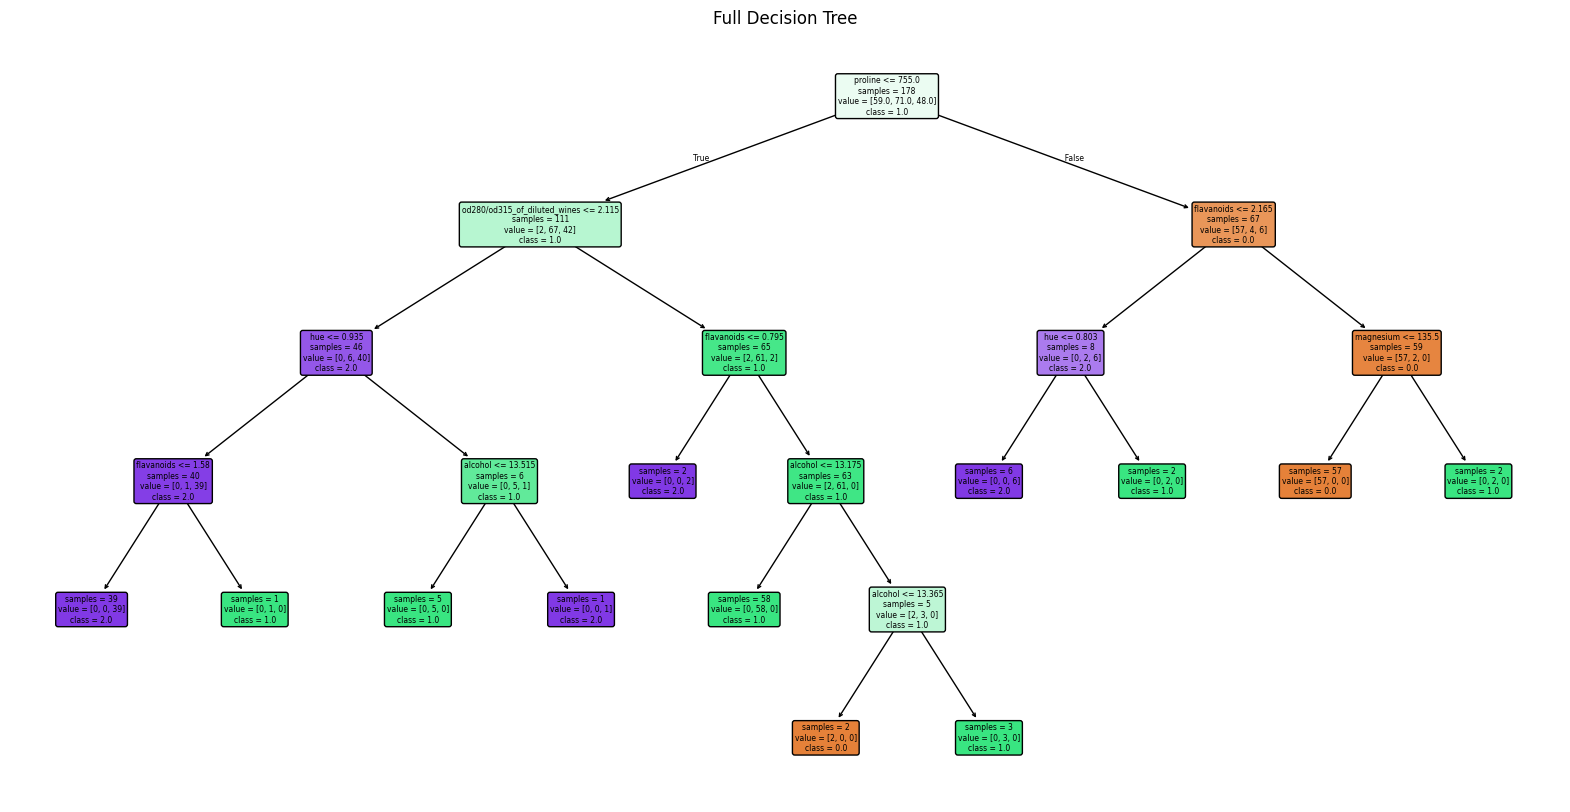

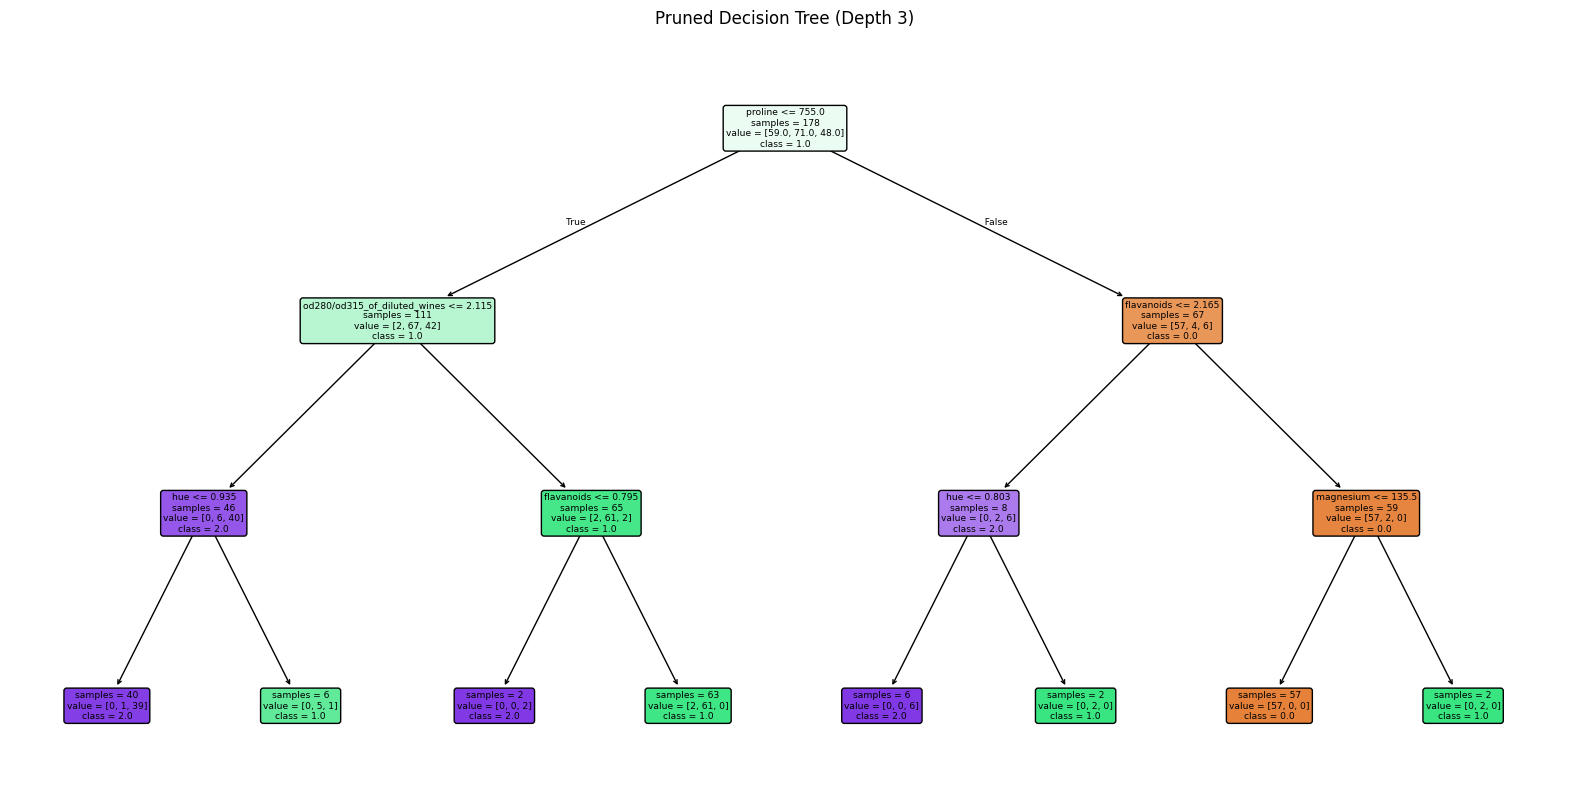

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


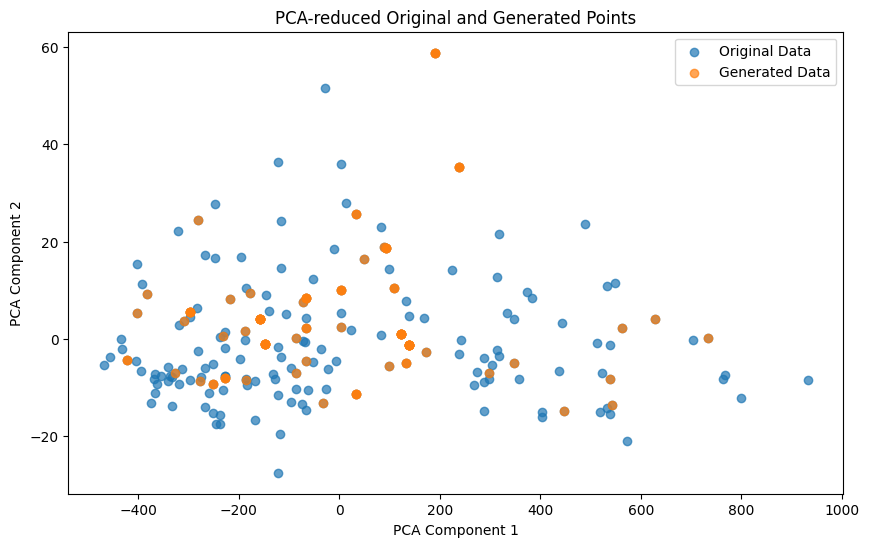

In [11]:
# User selection
print("Choose a dataset:")
print("1. Iris")
print("2. Wine")
print("3. Breast Cancer")
choice = input("Enter your choice (1, 2, or 3): ")

dataset_map = {"1": "iris", "2": "wine", "3": "cancer"}
dataset_choice = dataset_map.get(choice)

if dataset_choice:
    df, target_column = load_classification_dataset(dataset_choice)
    decision_tree_data_generation_with_pruning(
        df, target_column=target_column, max_depth=15, prune_depth=3, n_generated_points=100
    )
else:
    print("Invalid choice. Please run the program again and select a valid option.")

Choose a dataset:
1. Iris
2. Wine
3. Breast Cancer
Enter your choice (1, 2, or 3): 3


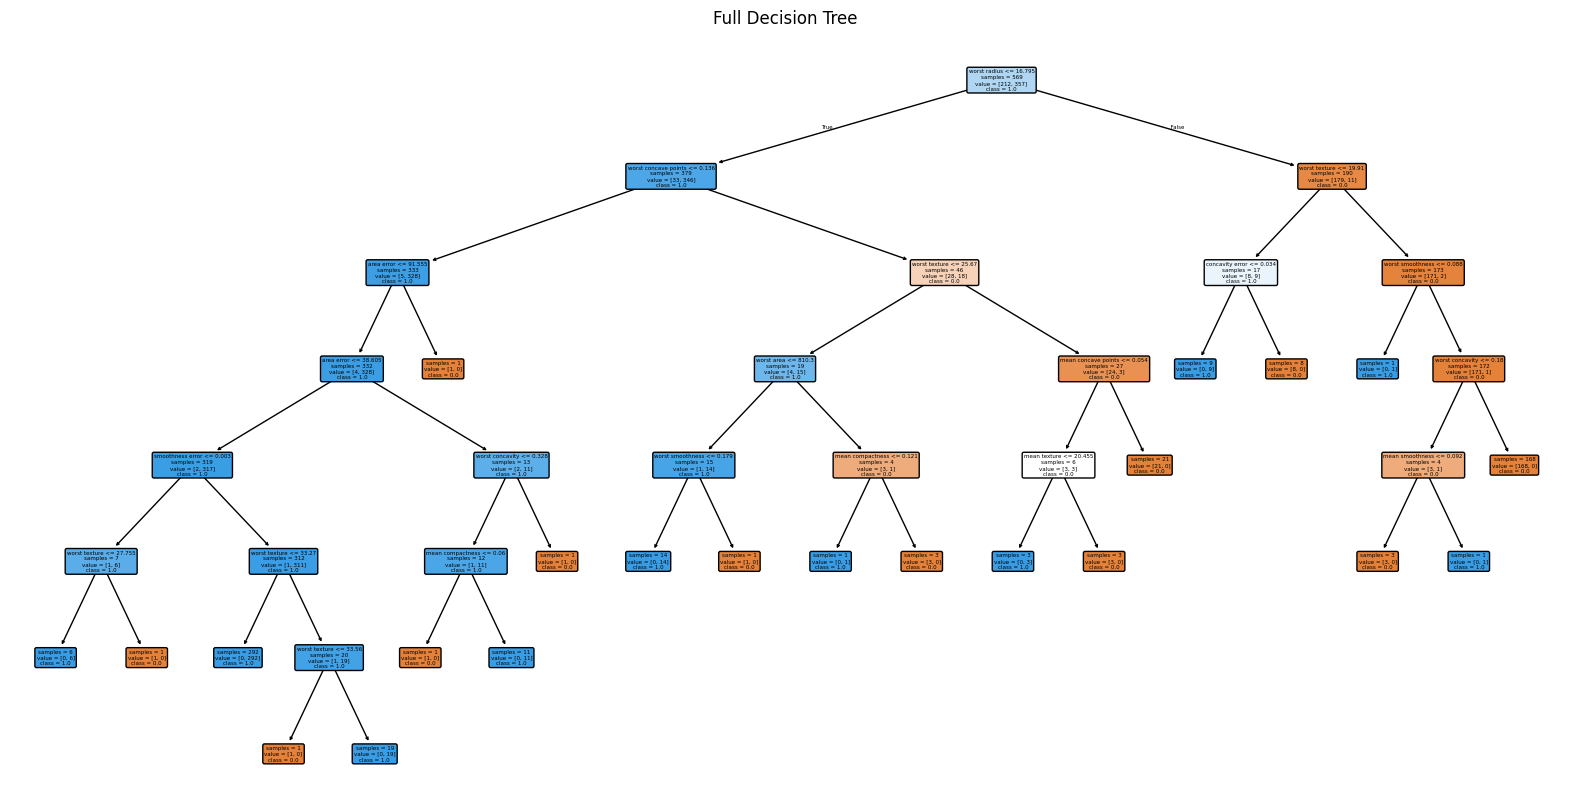

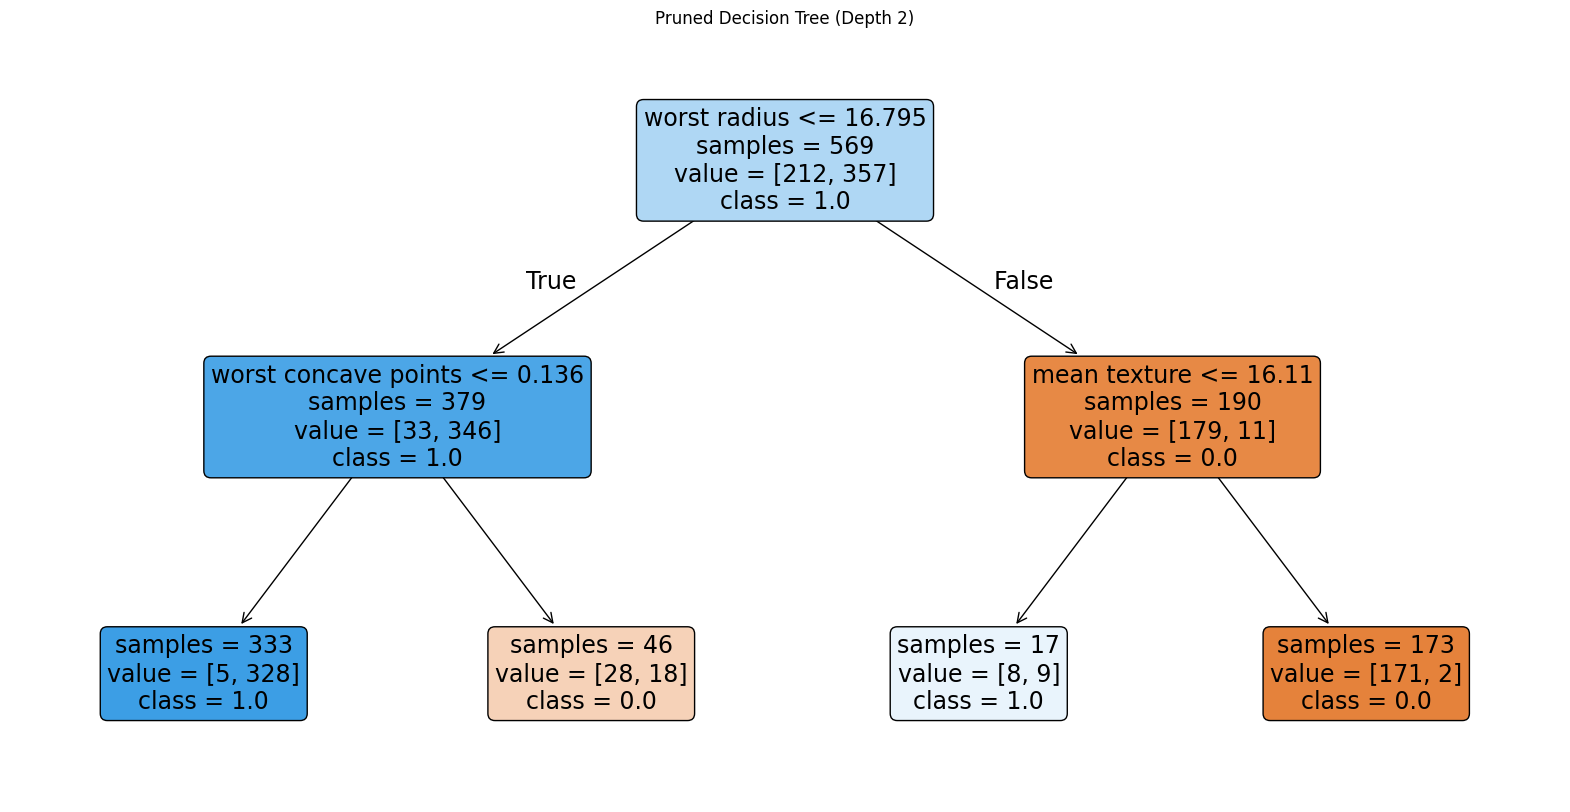

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


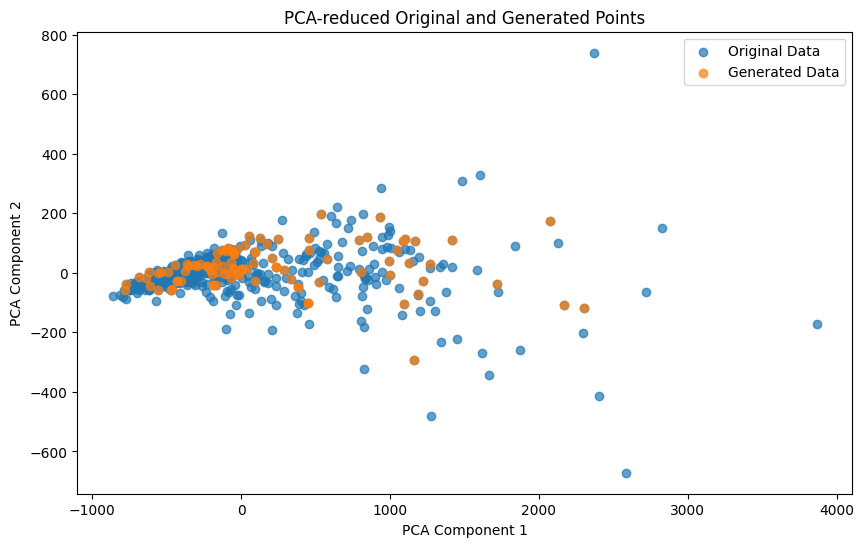

In [14]:
# User selection
print("Choose a dataset:")
print("1. Iris")
print("2. Wine")
print("3. Breast Cancer")
choice = input("Enter your choice (1, 2, or 3): ")

dataset_map = {"1": "iris", "2": "wine", "3": "cancer"}
dataset_choice = dataset_map.get(choice)

if dataset_choice:
    df, target_column = load_classification_dataset(dataset_choice)
    decision_tree_data_generation_with_pruning(
        df, target_column=target_column,  prune_depth=2, n_generated_points=100
    )
else:
    print("Invalid choice. Please run the program again and select a valid option.")

## Pruning until all classes exist

Checking tree at depth 1: Predicted classes = {0.0, 1.0}
Checking tree at depth 2: Predicted classes = {0.0, 1.0, 2.0}
All classes found at depth 2


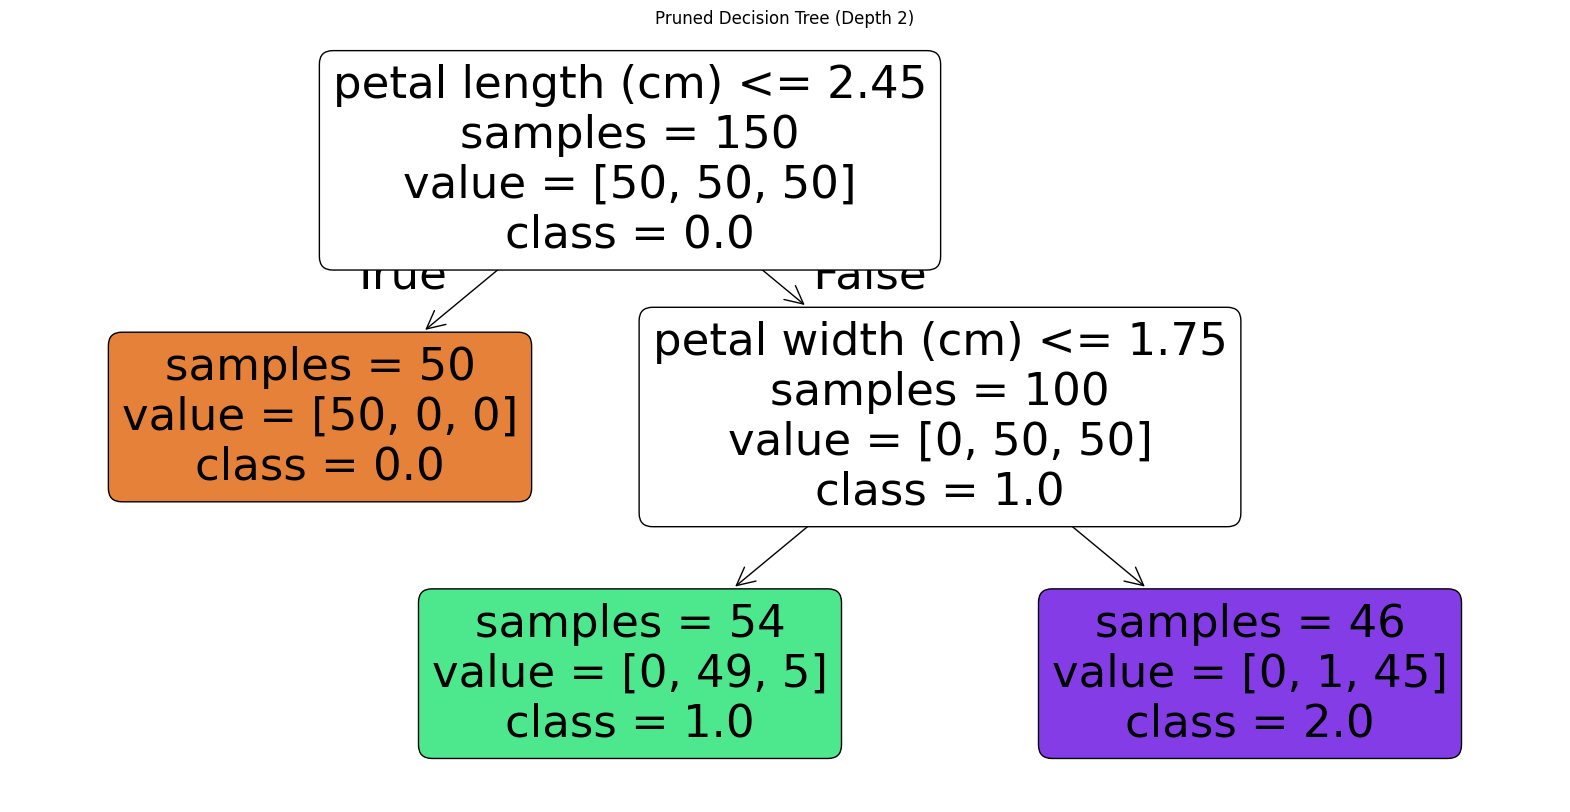

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


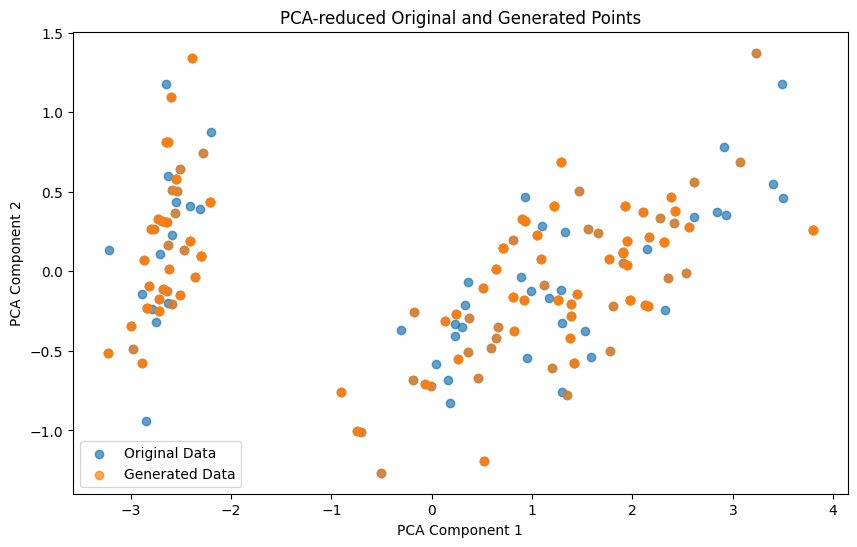

In [20]:
def decision_tree_data_generation_ensure_classes(df, target_column, max_depth=15, n_generated_points=100):
    """
    Builds a decision tree level by level, ensuring all classes are present in the pruned tree
    before generating data. If all classes are not present, it adds another level and retries.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - max_depth: Maximum depth of the decision tree.
    - n_generated_points: Number of new data points to generate.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    feature_names = X.columns.tolist()
    class_names = [str(cls) for cls in np.unique(y)]
    unique_classes = set(np.unique(y))
    
    # Build decision tree level by level
    for depth in range(1, max_depth + 1):
        tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
        tree.fit(X, y)
        
        # Check if all classes are present in the predictions
        predicted_classes = set(tree.predict(X))
        
        print(f"Checking tree at depth {depth}: Predicted classes = {predicted_classes}")
        if unique_classes.issubset(predicted_classes):
            print(f"All classes found at depth {depth}")
            plot_decision_tree(tree, feature_names, class_names, f"Pruned Decision Tree (Depth {depth})")
            break
    else:
        print("Not all classes could be represented within the specified max_depth.")
        return
    
    # Generate new data points based on the pruned tree
    def generate_from_tree(tree, X, n_samples):
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        generated_data = []
        for _ in range(n_samples):
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = (
                matching_rows.sample(1).values.flatten()
                if len(matching_rows) > 0
                else X.sample(1).values.flatten()
            )
            generated_data.append(sample)
        return np.array(generated_data)

    generated_points = generate_from_tree(tree, pd.DataFrame(X), n_generated_points)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    generated_points_2d = pca.transform(generated_points)
    
    # Plot original and generated points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0], original_points_2d[:, 1], label="Original Data", alpha=0.7)
    plt.scatter(generated_points_2d[:, 0], generated_points_2d[:, 1], label="Generated Data", alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Example usage
iris = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

decision_tree_data_generation_ensure_classes(
    df_iris, target_column='target', max_depth=15, n_generated_points=200
)

## similar to previous but with Laplace noise

Enter the noise scale for Laplace distribution (e.g., 0.1): 0.1
Checking tree at depth 1: Predicted classes = {0.0, 1.0}
Checking tree at depth 2: Predicted classes = {0.0, 1.0, 2.0}
All classes found at depth 2


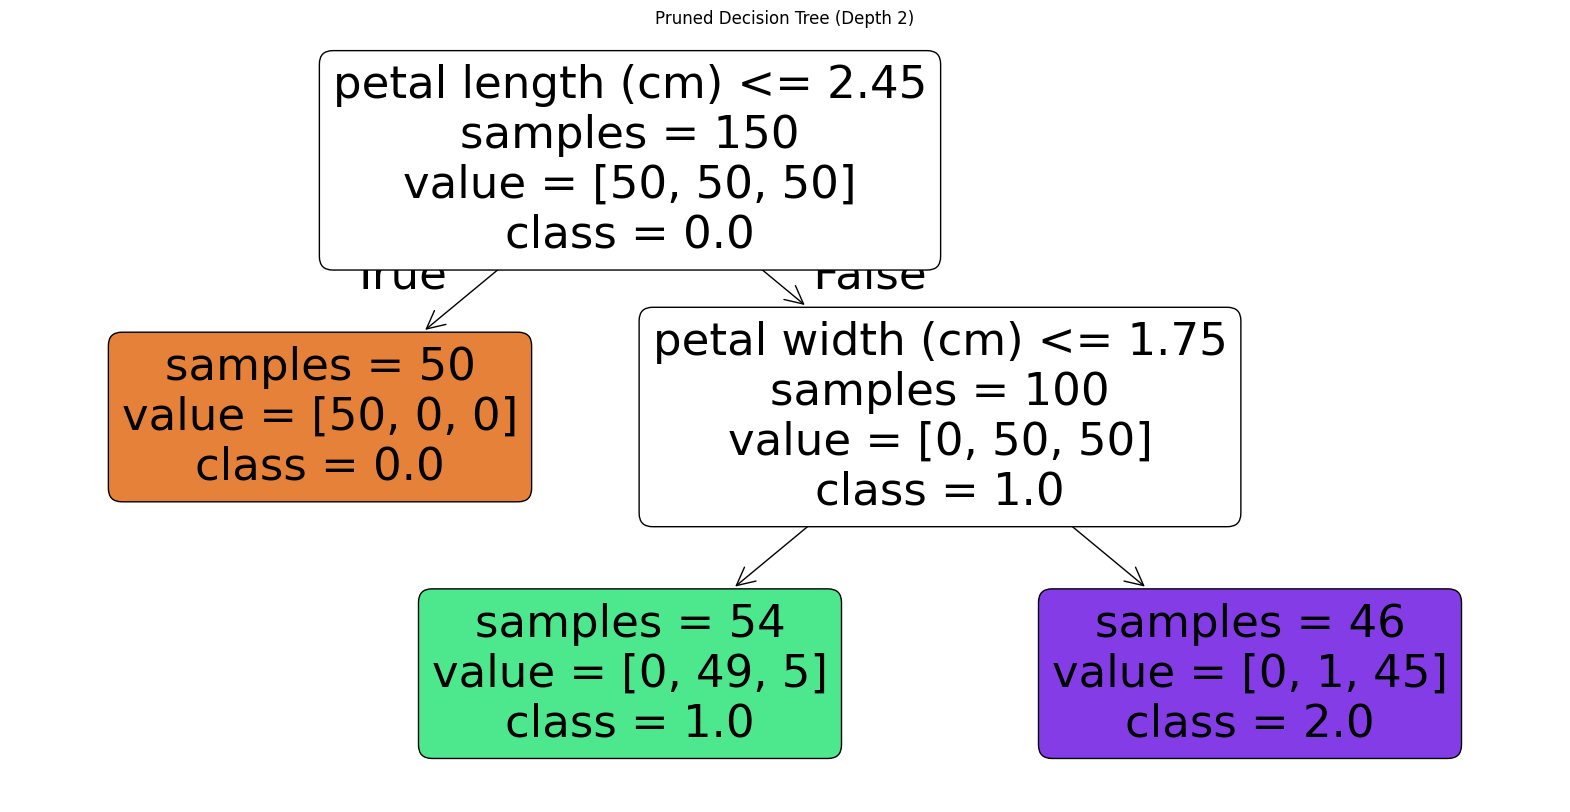

/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


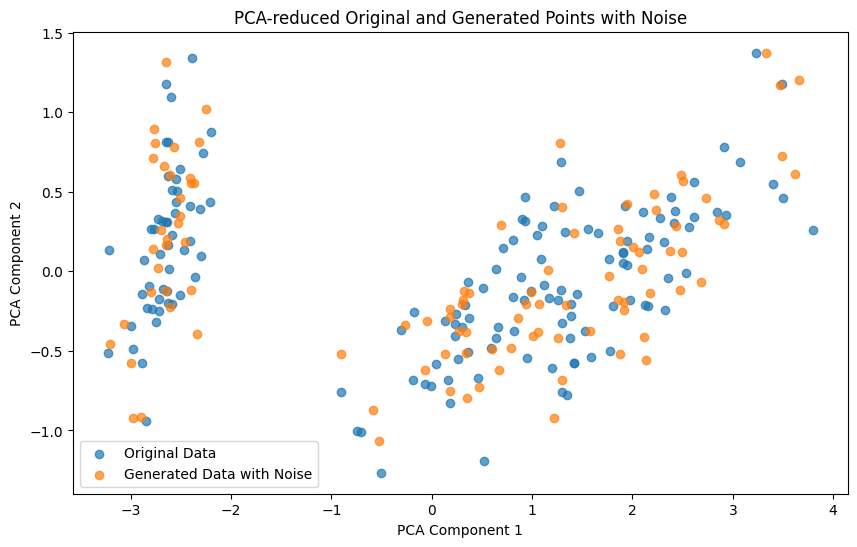

In [21]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

def plot_decision_tree(tree, feature_names, class_names, title):
    """
    Plots the decision tree using matplotlib.
    
    Parameters:
    - tree: The decision tree classifier.
    - feature_names: List of feature names.
    - class_names: List of class names.
    - title: Title of the plot.
    """
    plt.figure(figsize=(20, 10))
    plot_tree(tree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, impurity=False)
    plt.title(title)
    plt.show()

def add_laplace_noise(data, scale):
    """
    Adds Laplace noise to the data.
    
    Parameters:
    - data: NumPy array of data points.
    - scale: Scale parameter for the Laplace distribution.
    
    Returns:
    - Noisy data as a NumPy array.
    """
    noise = np.random.laplace(loc=0.0, scale=scale, size=data.shape)
    return data + noise

def decision_tree_data_generation_with_noise(df, target_column, max_depth=15, n_generated_points=100, noise_scale=0.1):
    """
    Builds a decision tree, ensures all classes are present, generates new data points with added noise,
    and plots PCA-reduced scatter plots of original and generated data.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - max_depth: Maximum depth of the decision tree.
    - n_generated_points: Number of new data points to generate.
    - noise_scale: Scale parameter for the Laplace noise.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    feature_names = X.columns.tolist()
    class_names = [str(cls) for cls in np.unique(y)]
    unique_classes = set(np.unique(y))
    
    # Build decision tree level by level
    for depth in range(1, max_depth + 1):
        tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
        tree.fit(X, y)
        
        # Check if all classes are present in the predictions
        predicted_classes = set(tree.predict(X))
        
        print(f"Checking tree at depth {depth}: Predicted classes = {predicted_classes}")
        if unique_classes.issubset(predicted_classes):
            print(f"All classes found at depth {depth}")
            plot_decision_tree(tree, feature_names, class_names, f"Pruned Decision Tree (Depth {depth})")
            break
    else:
        print("Not all classes could be represented within the specified max_depth.")
        return
    
    # Generate new data points based on the pruned tree
    def generate_from_tree(tree, X, n_samples):
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        generated_data = []
        for _ in range(n_samples):
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = (
                matching_rows.sample(1).values.flatten()
                if len(matching_rows) > 0
                else X.sample(1).values.flatten()
            )
            generated_data.append(sample)
        return np.array(generated_data)

    generated_points = generate_from_tree(tree, pd.DataFrame(X), n_generated_points)
    
    # Add Laplace noise to the generated data
    noisy_generated_points = add_laplace_noise(generated_points, noise_scale)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    noisy_generated_points_2d = pca.transform(noisy_generated_points)
    
    # Plot original and generated points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0], original_points_2d[:, 1], label="Original Data", alpha=0.7)
    plt.scatter(noisy_generated_points_2d[:, 0], noisy_generated_points_2d[:, 1], label="Generated Data with Noise", alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points with Noise")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Example usage
iris = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

# User input for noise scale
noise_scale = float(input("Enter the noise scale for Laplace distribution (e.g., 0.1): "))

decision_tree_data_generation_with_noise(
    df_iris, target_column='target', max_depth=15, n_generated_points=100, noise_scale=noise_scale
)

Enter the noise scale for Laplace distribution (e.g., 0.1): 0.03


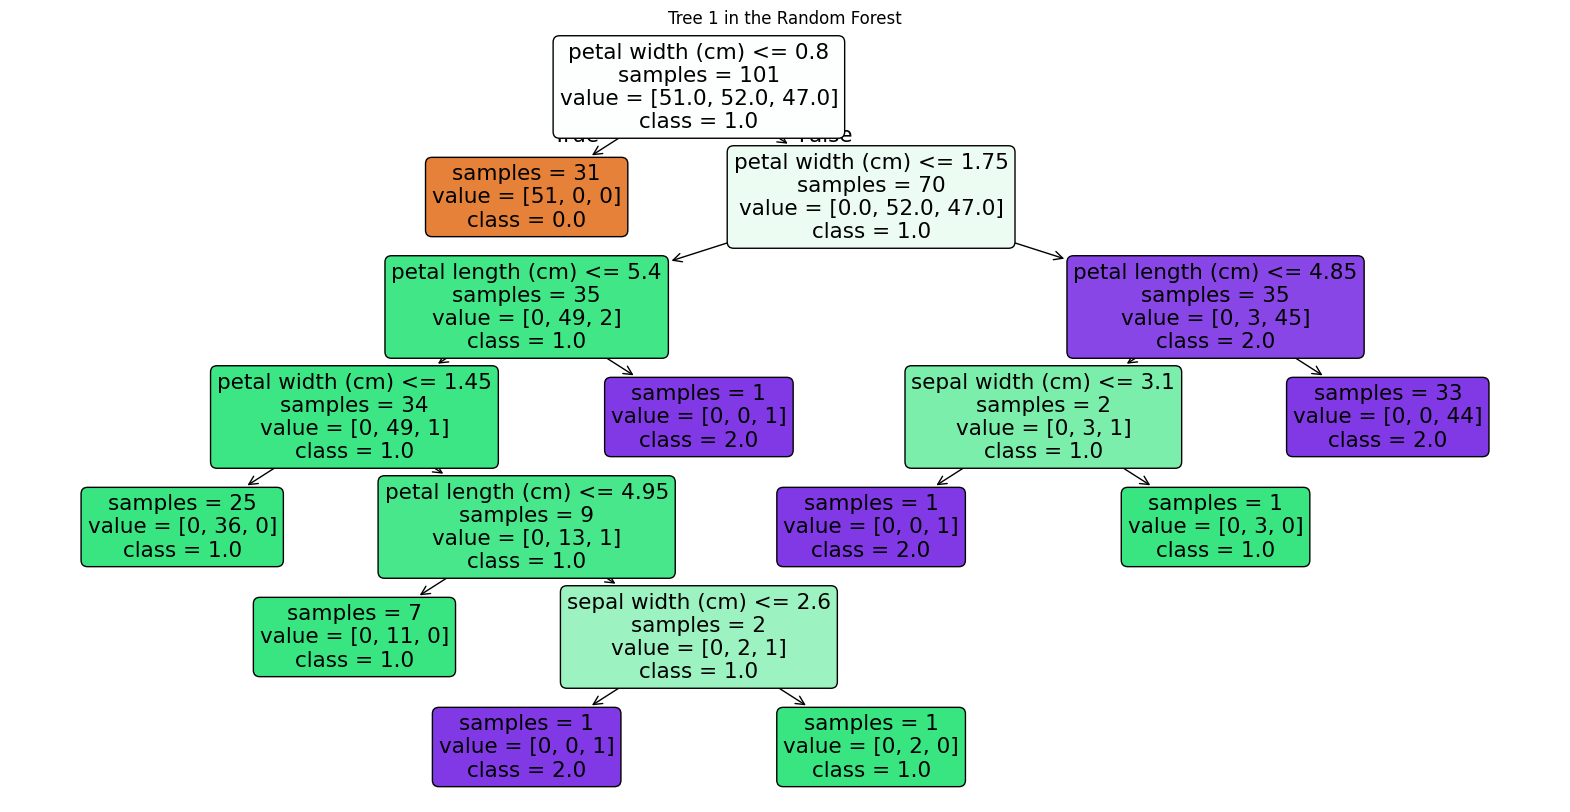

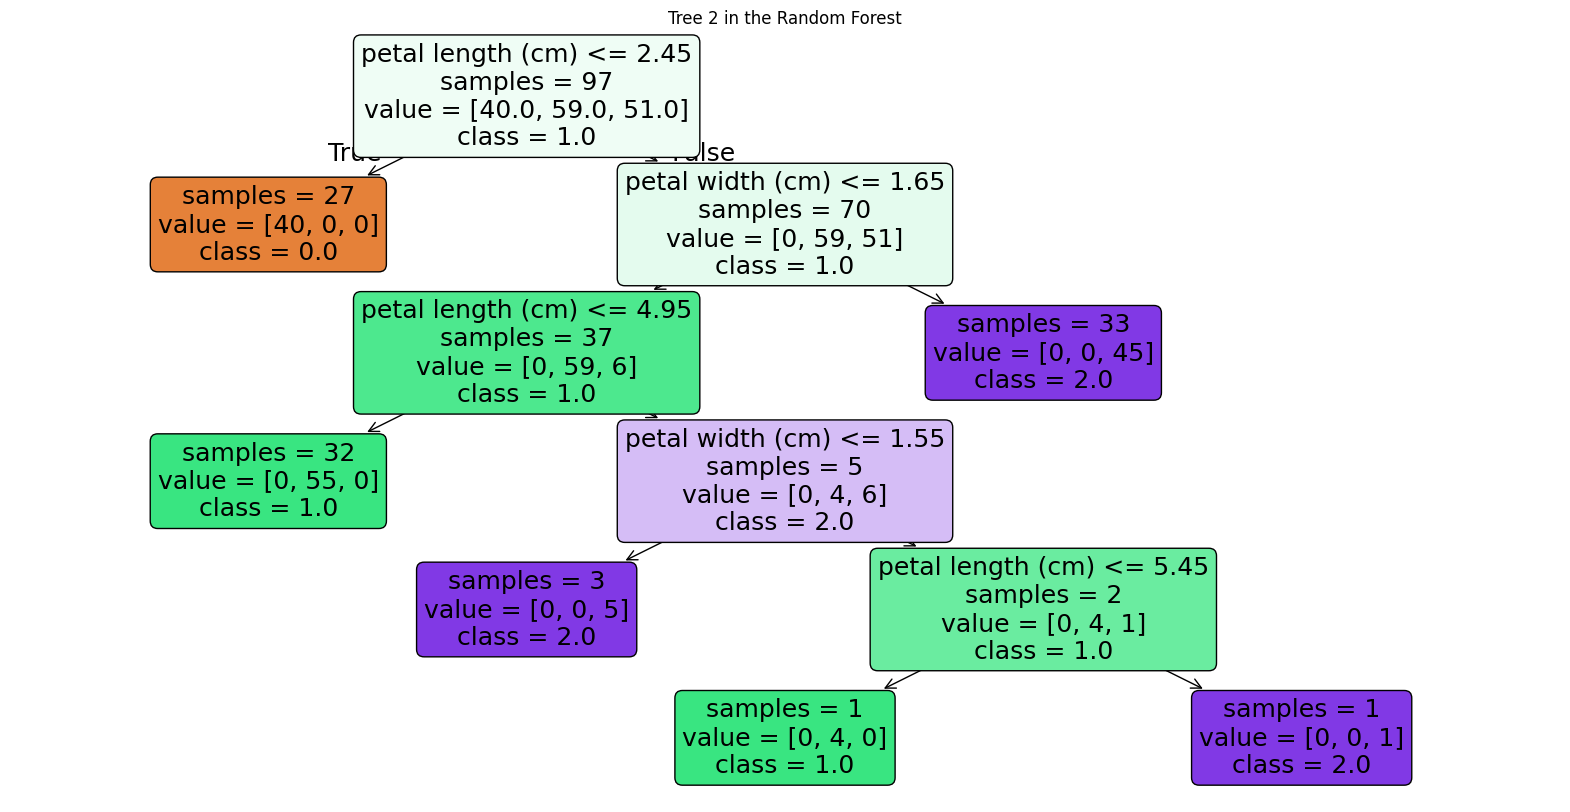

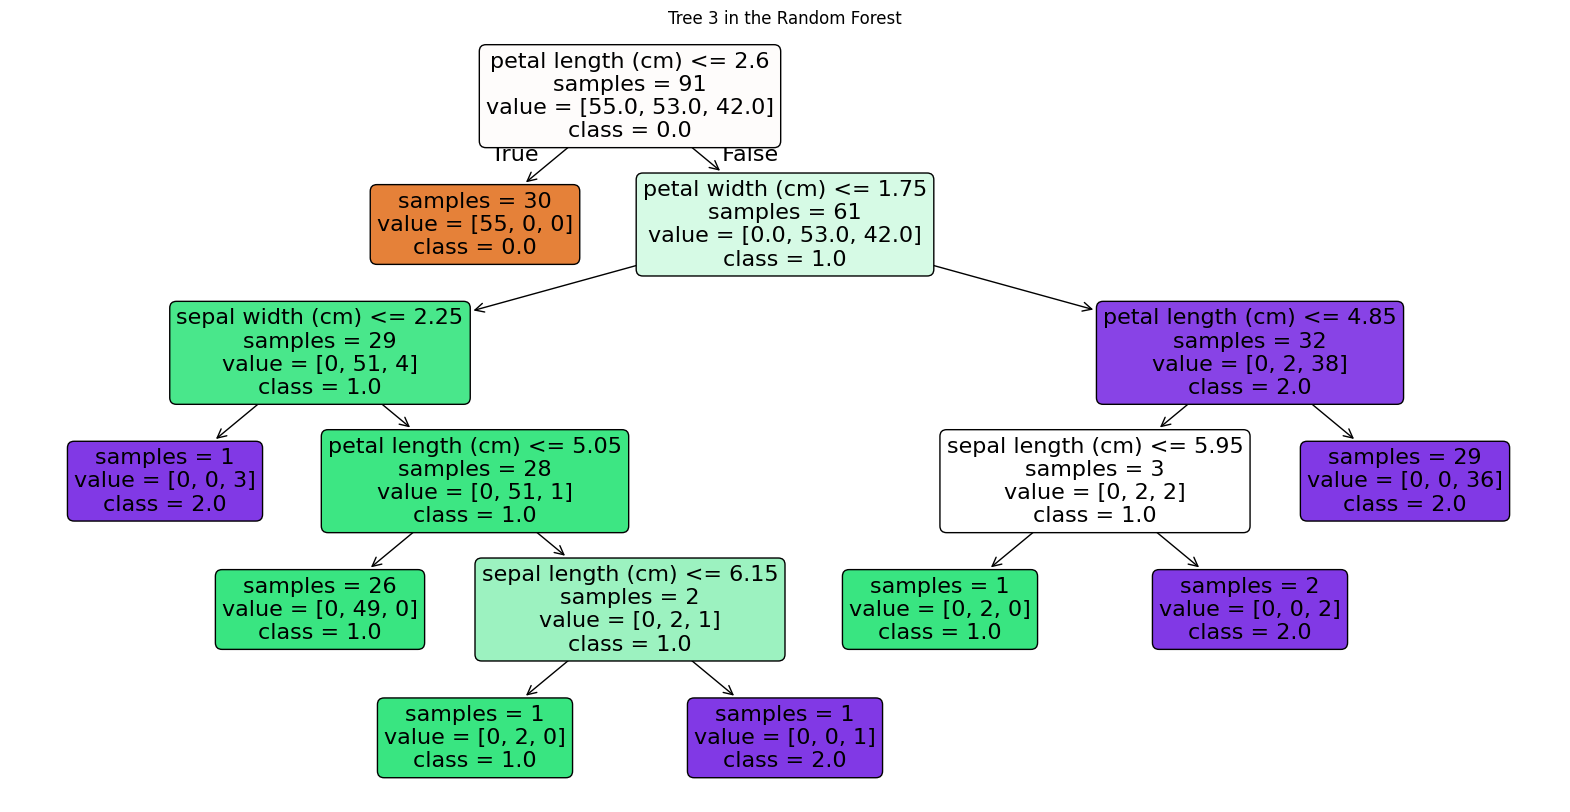

Total Variation Distance (TVD): 1.1133333333333324


/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/navid/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWar

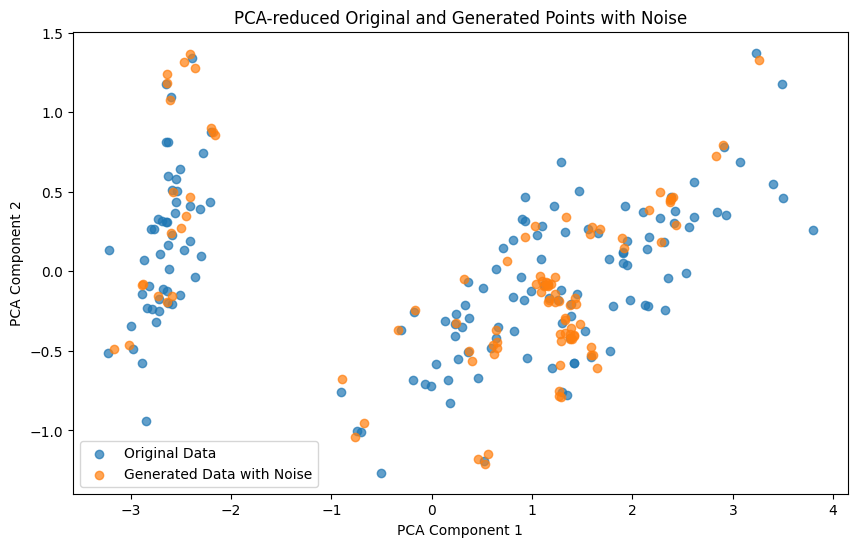

Original DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  

Synthetic DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           4.910509          3.012730           1.372023          0.216845   
1           7.204033          2.986102           5.773556          1.632007   
2           6.818628          2.920252           4.817013          1.396896   
3           5.715561          3.791002           1.713173          0.303909   
4           7.85

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
from scipy.stats import entropy
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


def plot_random_forest_trees(forest, feature_names, class_names, n_trees=3):
    """
    Plots a few trees from the random forest for visualization.
    
    Parameters:
    - forest: The random forest classifier.
    - feature_names: List of feature names.
    - class_names: List of class names.
    - n_trees: Number of trees to plot.
    """
    n_trees = min(n_trees, len(forest.estimators_))
    for i in range(n_trees):
        plt.figure(figsize=(20, 10))
        plot_tree(forest.estimators_[i],
                  feature_names=feature_names,
                  class_names=class_names,
                  filled=True,
                  rounded=True,
                  impurity=False)
        plt.title(f"Tree {i + 1} in the Random Forest")
        plt.show()


def add_laplace_noise(data, scale):
    """
    Adds Laplace noise to the data.
    
    Parameters:
    - data: NumPy array of data points.
    - scale: Scale parameter for the Laplace distribution.
    
    Returns:
    - Noisy data as a NumPy array.
    """
    noise = np.random.laplace(loc=0.0, scale=scale, size=data.shape)
    return data + noise


def calculate_tvd(original, synthetic, bins=10):
    """
    Calculates the Total Variation Distance (TVD) between two datasets.
    
    Parameters:
    - original: Original dataset (numpy array).
    - synthetic: Synthetic dataset (numpy array).
    - bins: Number of bins for discretizing the distributions.
    
    Returns:
    - TVD value.
    """
    tvd = 0
    for i in range(original.shape[1]):  # Iterate over each feature
        # Normalize histograms to represent probabilities
        orig_hist, _ = np.histogram(original[:, i], bins=bins, density=True)
        synth_hist, _ = np.histogram(synthetic[:, i], bins=bins, density=True)
        
        # Normalize histograms to sum to 1 (probabilities)
        orig_hist = orig_hist / np.sum(orig_hist)
        synth_hist = synth_hist / np.sum(synth_hist)
        
        # Calculate TVD for this feature
        tvd += 0.5 * np.sum(np.abs(orig_hist - synth_hist))
    
    return tvd

def random_forest_data_generation_with_tvd(df,
                                           target_column,
                                           n_trees=10,
                                           n_generated_points=100,
                                           noise_scale=0.1):
    """
    Generates synthetic data using a random forest, calculates Total Variation Distance (TVD),
    and returns two DataFrames: original and synthetic.
    
    Parameters:
    - df: DataFrame containing the data.
    - target_column: Column name for the target variable.
    - n_trees: Number of trees in the random forest.
    - n_generated_points: Number of new data points to generate.
    - noise_scale: Scale parameter for the Laplace noise.
    
    Returns:
    - original_df: DataFrame for the original data.
    - synthetic_df: DataFrame for the synthetic data.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    feature_names = X.columns.tolist()
    class_names = [str(cls) for cls in np.unique(y)]
    unique_classes = set(np.unique(y))

    # Train a random forest
    forest = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    forest.fit(X, y)

    # Visualize some trees in the forest
    plot_random_forest_trees(forest, feature_names, class_names, n_trees=3)

    # Generate synthetic data from each tree in the forest
    synthetic_data = []
    for tree in forest.estimators_:
        # Check if all classes are represented in this tree
        predicted_classes = set(tree.predict(X))
        if not unique_classes.issubset(predicted_classes):
            print(
                f"Tree missing classes: {unique_classes - predicted_classes}")
            continue

        # Generate data points from the tree
        leaf_indices = tree.apply(X)
        leaves = np.unique(leaf_indices)
        tree_data = []
        for _ in range(
                n_generated_points //
                n_trees):  # Generate a fraction of points from each tree
            leaf = np.random.choice(leaves)
            matching_rows = X[leaf_indices == leaf]
            sample = (matching_rows.sample(1).values.flatten() if
                      len(matching_rows) > 0 else X.sample(1).values.flatten())
            tree_data.append(sample)
        synthetic_data.extend(tree_data)

    synthetic_data = np.array(synthetic_data)

    # Add Laplace noise to the synthetic data
    noisy_synthetic_data = add_laplace_noise(synthetic_data, noise_scale)

    # Calculate Total Variation Distance
    tvd = calculate_tvd(X.values, noisy_synthetic_data)
    print(f"Total Variation Distance (TVD): {tvd}")

    # Create synthetic DataFrame
    synthetic_df = pd.DataFrame(data=noisy_synthetic_data,
                                columns=feature_names)
    synthetic_df[target_column] = np.random.choice(
        y.unique(), size=len(synthetic_df))  # Assign random target

    # Perform PCA for visualization
    pca = PCA(n_components=2)
    original_points_2d = pca.fit_transform(X)
    noisy_synthetic_points_2d = pca.transform(noisy_synthetic_data)

    # Plot original and synthetic points
    plt.figure(figsize=(10, 6))
    plt.scatter(original_points_2d[:, 0],
                original_points_2d[:, 1],
                label="Original Data",
                alpha=0.7)
    plt.scatter(noisy_synthetic_points_2d[:, 0],
                noisy_synthetic_points_2d[:, 1],
                label="Generated Data with Noise",
                alpha=0.7)
    plt.legend()
    plt.title("PCA-reduced Original and Generated Points with Noise")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

    # Return original and synthetic DataFrames
    original_df = df.copy()
    return original_df, synthetic_df


# Example usage
iris = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['target'])

# User input for noise scale
noise_scale = float(
    input("Enter the noise scale for Laplace distribution (e.g., 0.1): "))

original_df, synthetic_df = random_forest_data_generation_with_tvd(
    df_iris,
    target_column='target',
    n_trees=10,
    n_generated_points=100,
    noise_scale=noise_scale)

# Display DataFrames
print("Original DataFrame:")
print(original_df.head())
print("\nSynthetic DataFrame:")
print(synthetic_df.head())

In [27]:
original_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [28]:
synthetic_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,5.929141,3.040668,4.170265,1.383169,1.080000
std,0.669847,0.468907,1.510901,0.666772,0.849004
min,4.323000,2.151872,1.183915,0.025030,0.000000
25%,5.641900,2.730896,3.575759,1.078807,0.000000
50%,5.924629,2.991257,4.806506,1.560032,1.000000
75%,6.243948,3.229876,5.096346,1.782177,2.000000
max,7.850105,4.404752,6.459489,2.531165,2.000000
